In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

#### how does the ImageDataGenerator works

1. Image is loaded from disk

2. Resized to target_size

3. Transformations (shear, zoom, flip) from ImageDataGenerator are applied

4. Rescaling is done (like converting from 0–255 to 0–1)

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2,horizontal_flip=True)

In [4]:
train_generator = datagen.flow_from_directory('dataset/training_set',target_size=(64,64), class_mode="binary")

Found 7115 images belonging to 2 classes.


In [5]:
test_generator = datagen.flow_from_directory('dataset/test_set',target_size=(64,64), class_mode="binary")

Found 496 images belonging to 2 classes.


In [6]:
train_generator

In [7]:
data,lable = next(train_generator)  #generates 32 imagges& their labels from out training data
data.shape

(32, 64, 64, 3)

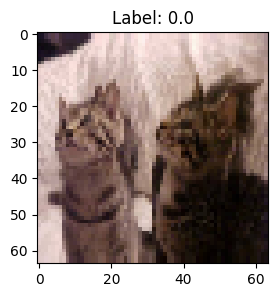

In [8]:


plt.figure(figsize=(3,3))
plt.imshow(data[0])   # from 32 images take first image
plt.title(f"Label: {lable[0]}") #take label of first image & show it as title of image
plt.show()

In [9]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [10]:
cnn = tf.keras.models.Sequential()

In [11]:
#convolution window
# filters: tells the no. of feature detectors
#kernel size : window 
#input size: as we have 64x64 images with 3 shades (RGB)
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu", input_shape=[64,64,3]))

C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
#stride: overlapping matrics

cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [13]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [14]:
cnn.add(tf.keras.layers.Flatten())

In [15]:
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [16]:
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))  #output layer

In [17]:
cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [18]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
result = cnn.fit(x = train_generator ,epochs = 5)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
223/223 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.5793 - loss: 0.6705
Epoch 2/5
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.6937 - loss: 0.5801
Epoch 3/5
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.7250 - loss: 0.5406
Epoch 4/5
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.7434 - loss: 0.5138
Epoch 5/5
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.7373 - loss: 0.5127


In [20]:
cnn.evaluate(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.8299 - loss: 0.3864


[0.3785364627838135, 0.8306451439857483]

In [21]:
pred =cnn.predict(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step


In [22]:
predicted_classes = []
for x in pred:
    if(x >0.5):
        predicted_classes.append(1)
    else:
        predicted_classes.append(0)
predicted_classes

[1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,


In [23]:
true_classes =test_generator.classes

In [24]:
class_labels = list(test_generator.class_indices.keys())
for i in range(len(true_classes)):
    actual_label = class_labels[true_classes[i]]
    predicted_label = class_labels[predicted_classes[i]]
    print(f"Image {i+1}: Actual = {actual_label}, Predicted = {predicted_label}")

Image 1: Actual = cats, Predicted = dogs
Image 2: Actual = cats, Predicted = dogs
Image 3: Actual = cats, Predicted = cats
Image 4: Actual = cats, Predicted = dogs
Image 5: Actual = cats, Predicted = dogs
Image 6: Actual = cats, Predicted = dogs
Image 7: Actual = cats, Predicted = cats
Image 8: Actual = cats, Predicted = cats
Image 9: Actual = cats, Predicted = dogs
Image 10: Actual = cats, Predicted = cats
Image 11: Actual = cats, Predicted = dogs
Image 12: Actual = cats, Predicted = dogs
Image 13: Actual = cats, Predicted = dogs
Image 14: Actual = cats, Predicted = cats
Image 15: Actual = cats, Predicted = dogs
Image 16: Actual = cats, Predicted = dogs
Image 17: Actual = cats, Predicted = cats
Image 18: Actual = cats, Predicted = dogs
Image 19: Actual = cats, Predicted = dogs
Image 20: Actual = cats, Predicted = dogs
Image 21: Actual = cats, Predicted = dogs
Image 22: Actual = cats, Predicted = cats
Image 23: Actual = cats, Predicted = dogs
Image 24: Actual = cats, Predicted = dogs
I

In [25]:
#predict a new data
import numpy as np
from keras.preprocessing import image
from keras.utils import load_img
from keras.utils import img_to_array
test_image = load_img('dataset/single_prediction/OIP.jfif', target_size = (64, 64))

#convert te image object to array

test_image = img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
train_set.class_indices
if result[0][0] == 1:
  prediction = 'dog'
else:
  prediction = 'cat'
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


NameError: name 'train_set' is not defined

In [ ]:

# ✅ Save trained model in HDF5 format
model.save("model.h5", save_format="h5")
print("✅ Model saved as model.h5")

# ✅ Also save in TensorFlow SavedModel format (backup)
model.save("model")
print("✅ Model saved in TensorFlow SavedModel format")
